<a href="https://colab.research.google.com/github/onedmilson/fast_fire_detection/blob/main/PI_IV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install ultralytics
!pip install roboflow

In [ ]:
import ultralytics
from roboflow import Roboflow
from ultralytics import YOLO
from IPython.display import Image

In [ ]:
rf = Roboflow(api_key="vkn5JvocSSwADTJG87VP")
project = rf.workspace("-jwzpw").project("continuous_fire")
version = project.version(6)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...


In [ ]:
%%writefile /content/continuous_fire-6/data.yaml
names:
- fire
nc: 1
roboflow:
  license: CC BY 4.0
  project: continuous_fire
  url: https://universe.roboflow.com/-jwzpw/continuous_fire/dataset/6
  version: 6
  workspace: -jwzpw
test: /content/continuous_fire-6/test/images
train: /content/continuous_fire-6/train/images
val: /content/continuous_fire-6/valid/images

Overwriting /content/continuous_fire-6/data.yaml


In [ ]:
!yolo task=detect mode=train model=yolov8s.pt data=/content/continuous_fire-6/data.yaml epochs=10 imgsz=640 plots=True

Ultralytics 8.3.32 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
engine/trainer: task=detect, mode=train, model=yolov8s.pt, data=/content/continuous_fire-6/data.yaml, epochs=10, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train3, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True,

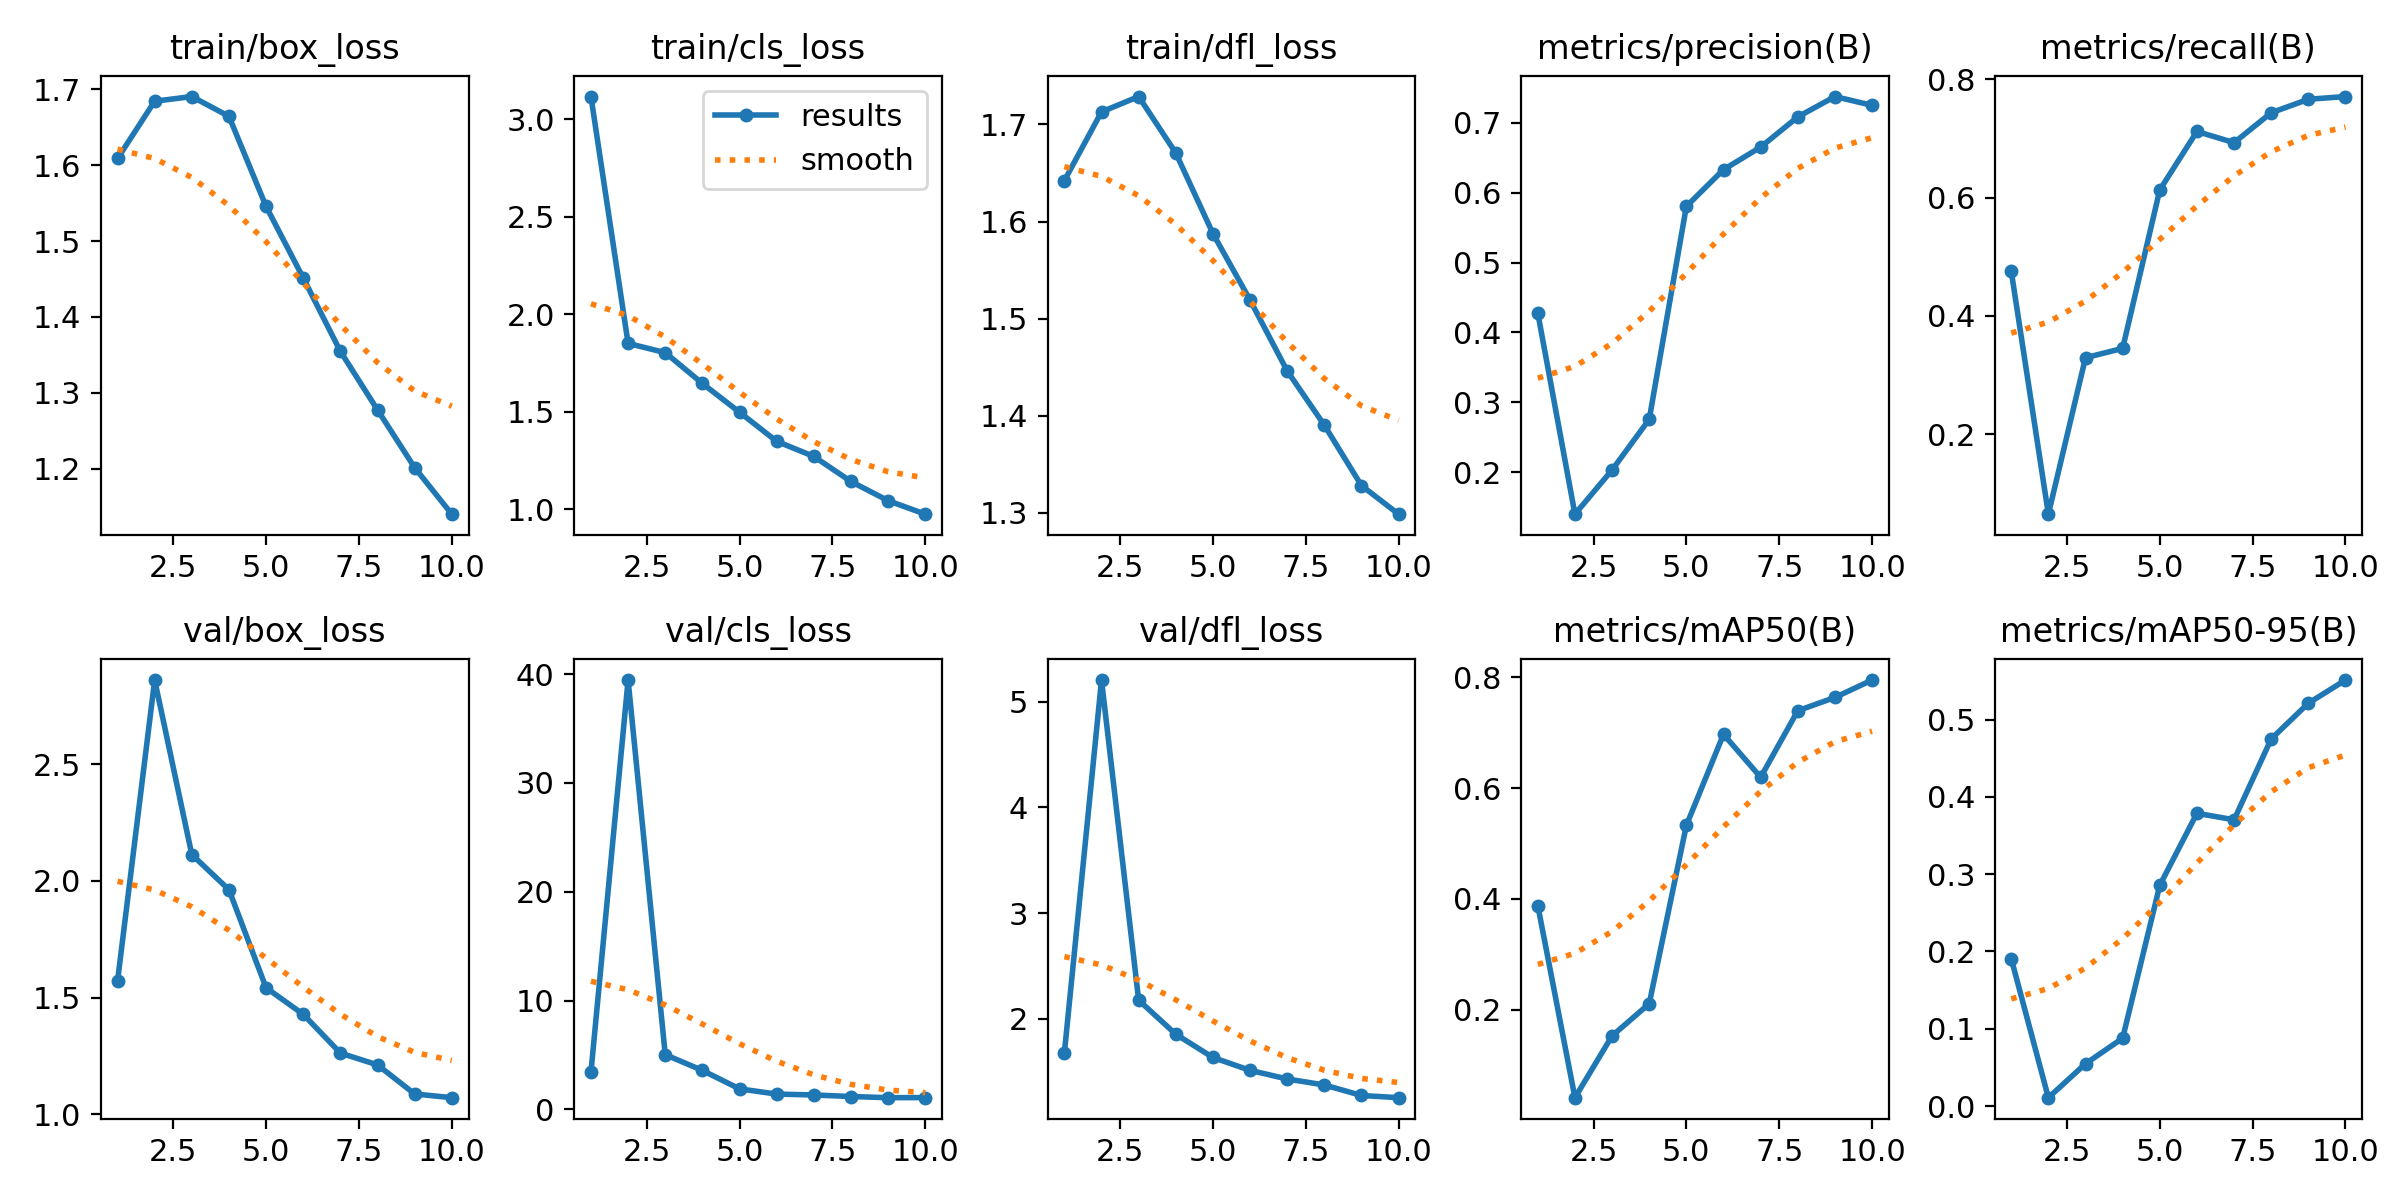

In [ ]:
Image(filename='/content/runs/detect/train/results.png', width=600)

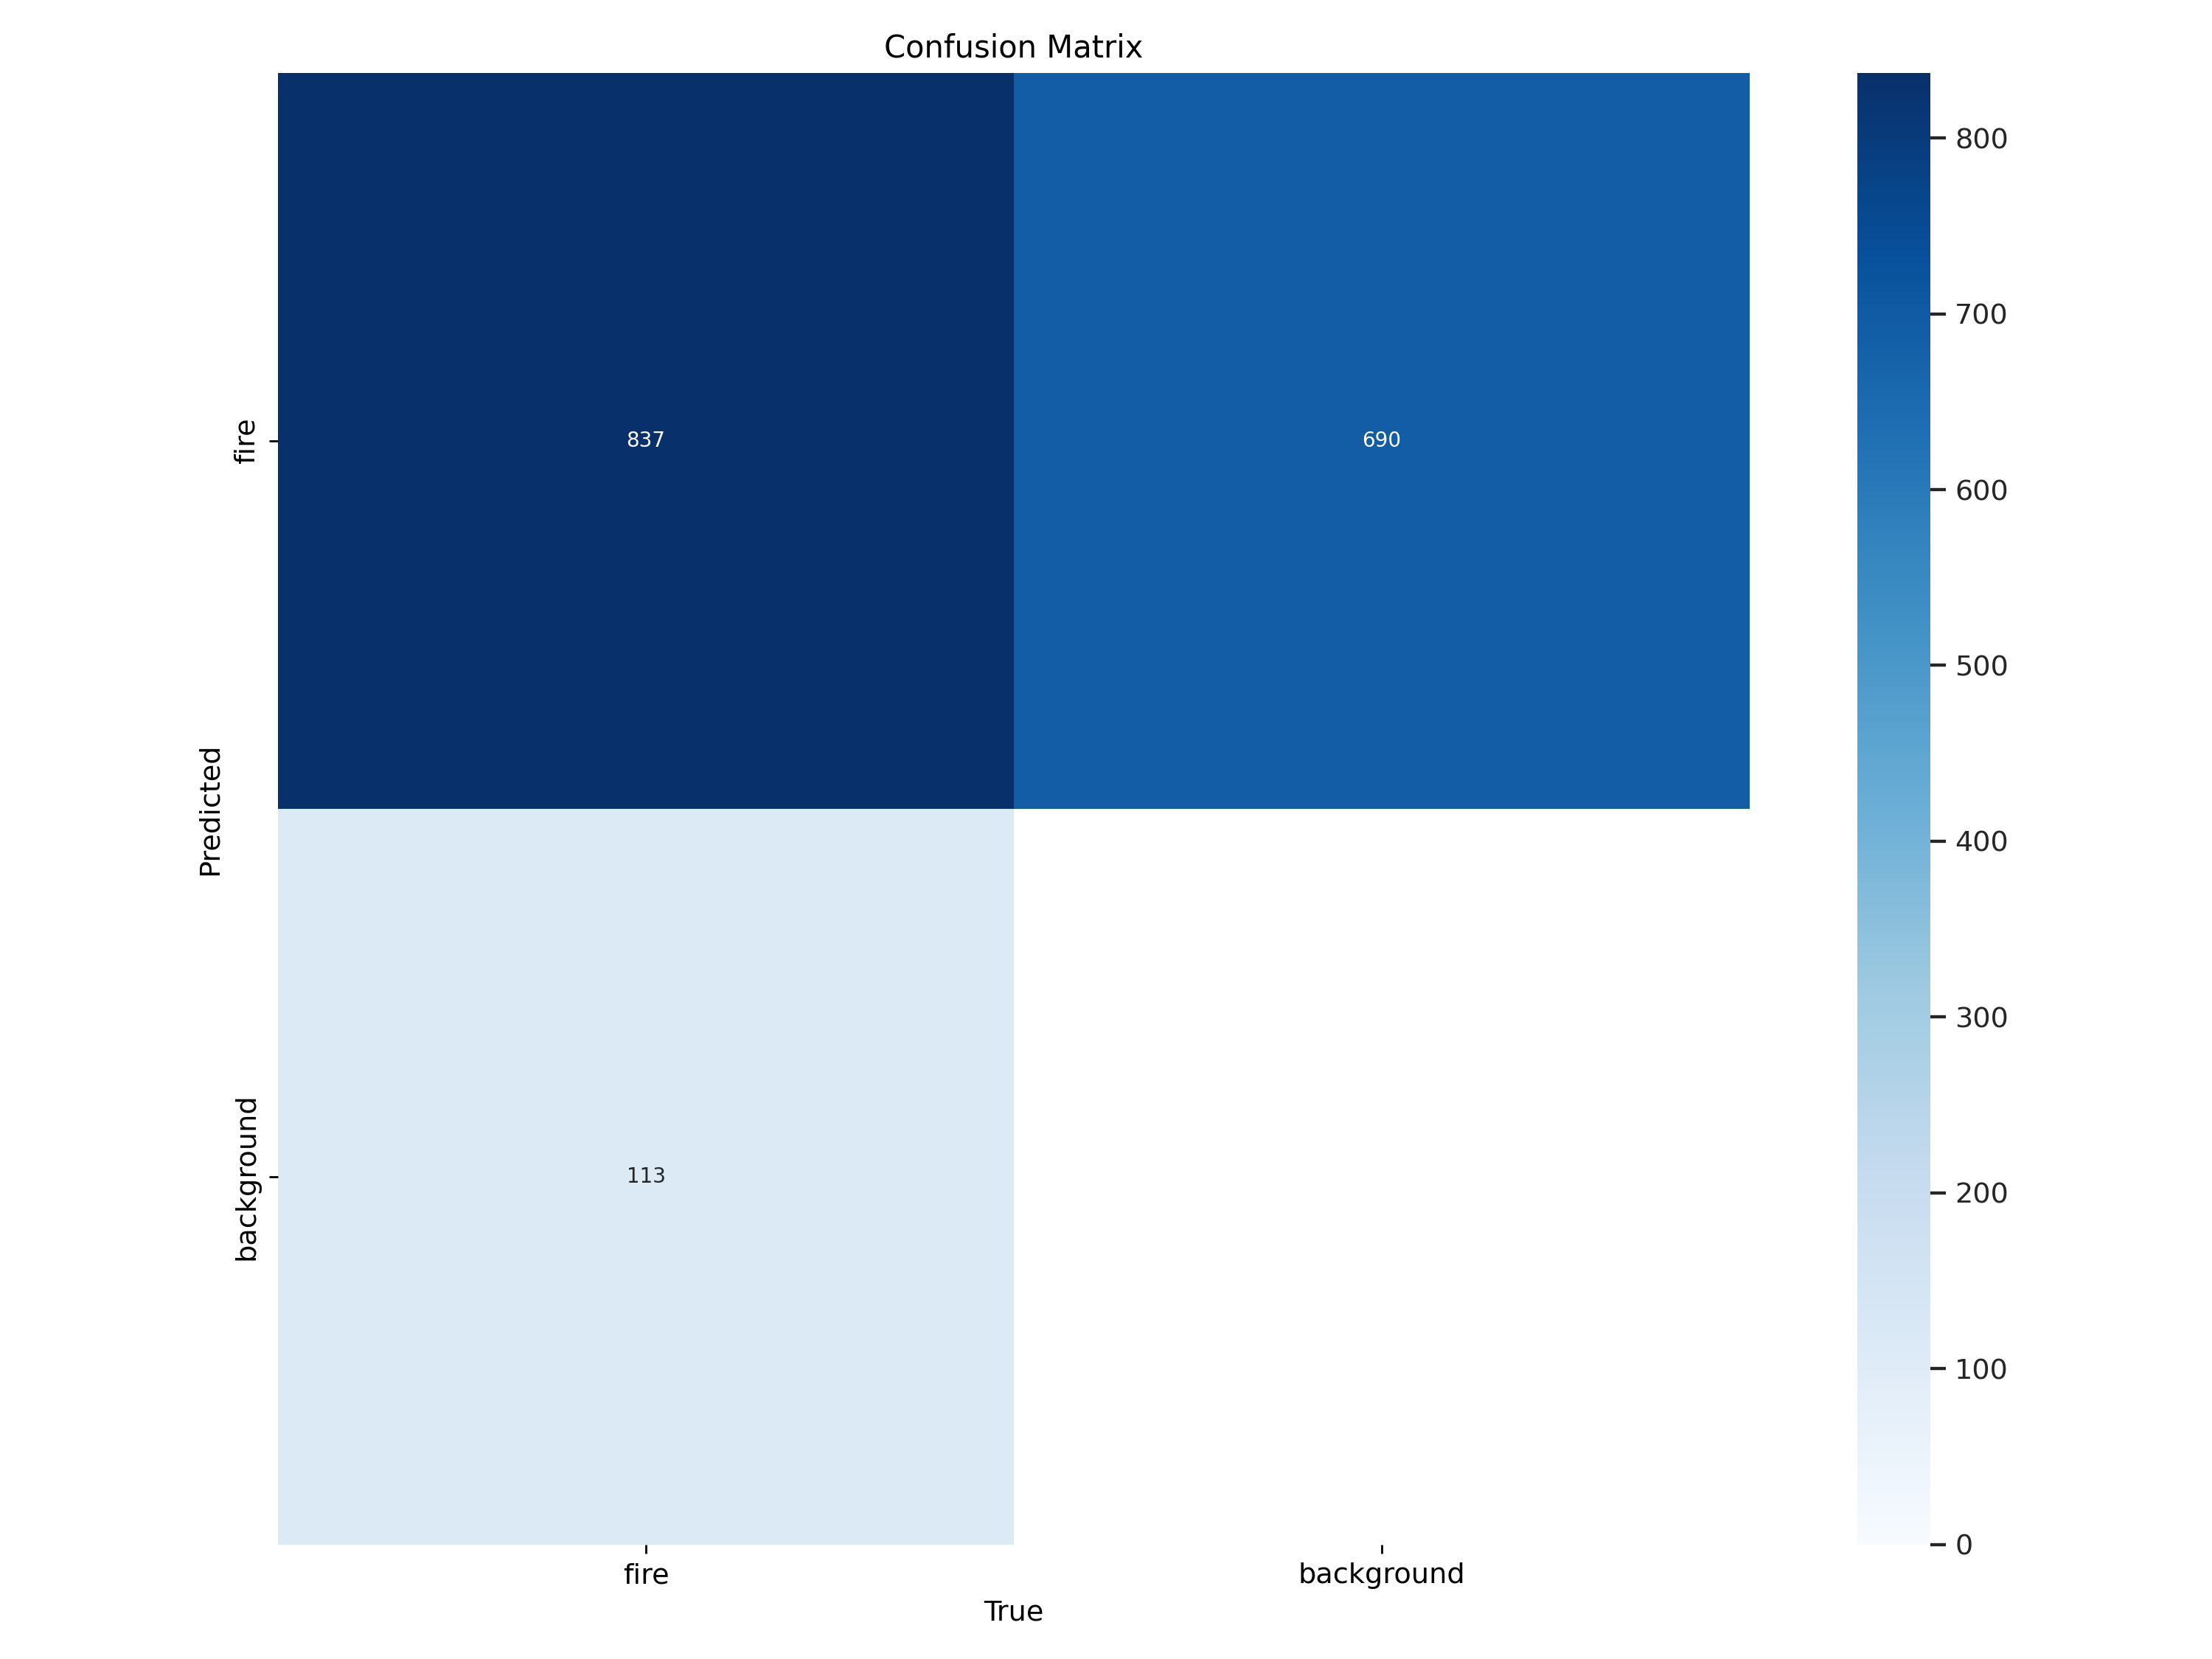

In [ ]:
Image(filename='/content/runs/detect/train/confusion_matrix.png', width=600)

In [ ]:
!yolo task=detect mode=val model=/content/runs/detect/train/weights/best.pt data=/content/continuous_fire-6/data.yaml

Ultralytics 8.3.32 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
Model summary (fused): 168 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Scanning /content/continuous_fire-6/valid/labels.cache... 754 images, 2 backgrounds, 0 corrupt: 100% 754/754 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 48/48 [00:11<00:00,  4.24it/s]
                   all        754        950       0.73      0.766      0.795      0.552
Speed: 0.6ms preprocess, 8.8ms inference, 0.0ms loss, 1.8ms postprocess per image
Results saved to runs/detect/val
💡 Learn more at https://docs.ultralytics.com/modes/val


Saving WhatsApp Image 2024-11-17 at 19.59.17 (6).jpeg to WhatsApp Image 2024-11-17 at 19.59.17 (6).jpeg

image 1/1 /content/WhatsApp Image 2024-11-17 at 19.59.17 (6).jpeg: 640x448 1 fire, 12.7ms
Speed: 3.1ms preprocess, 12.7ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 448)
Results saved to runs/detect/predict4
Pasta de saída dos resultados: runs/detect/predict4
Arquivos gerados: ['WhatsApp Image 2024-11-17 at 19.59.17 (6).jpg']


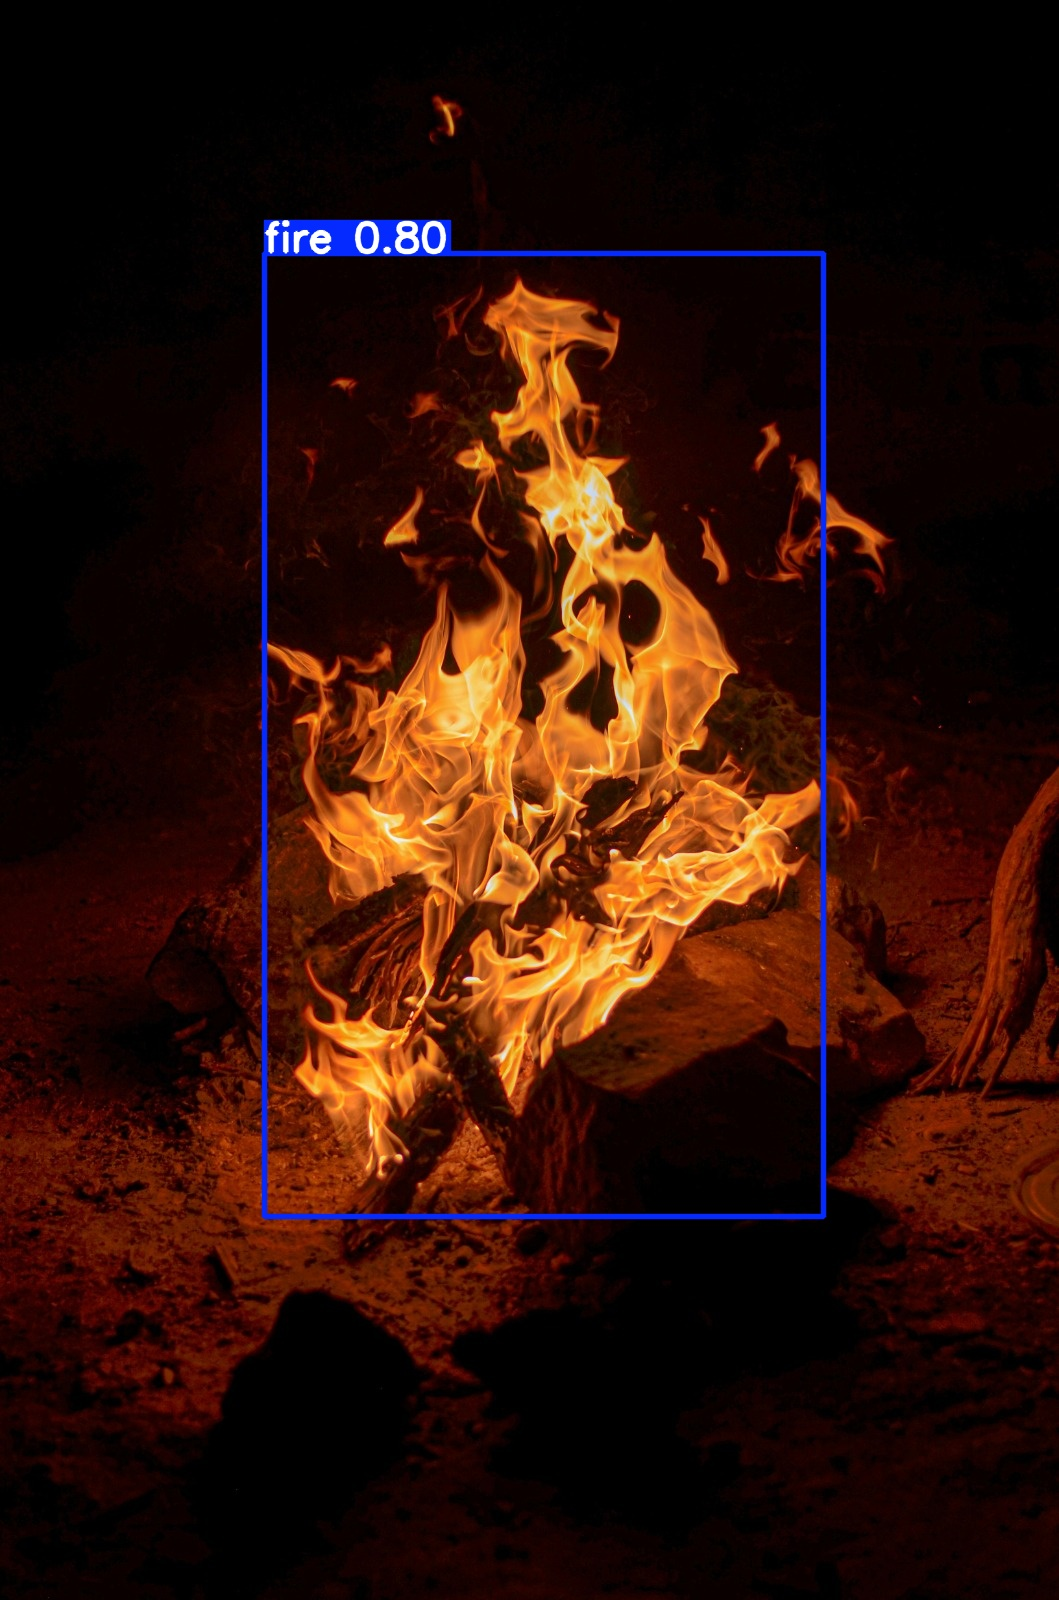

Fogo detectado com confiança de 0.80


In [ ]:
from ultralytics import YOLO
from IPython.display import Image, display
from google.colab import files
import os

uploaded = files.upload()
uploaded_image_path = list(uploaded.keys())[0]

model = YOLO('/content/runs/detect/train/weights/best.pt')

results = model.predict(source=uploaded_image_path, imgsz=640, conf=0.6, save=True)

save_dir = results[0].save_dir
print("Pasta de saída dos resultados:", save_dir)

print("Arquivos gerados:", os.listdir(save_dir))

processed_image_name = os.listdir(save_dir)[0]
processed_image_path = os.path.join(save_dir, processed_image_name)

if os.path.exists(processed_image_path):
    display(Image(filename=processed_image_path, width=400))
else:
    print("Imagem processada não encontrada:", processed_image_path)

if len(results[0].boxes) > 0:
    detected_class = results[0].boxes.cls[0].item()
    confidence = results[0].boxes.conf[0].item()

    if detected_class == 0 and confidence >= 0.6:
        message = "Fogo detectado com confiança de {:.2f}".format(confidence)
    else:
        message = "Fogo não detectado"
else:
    message = "Nenhuma detecção realizada"

print(message)

